<a href="https://colab.research.google.com/github/joynard/hacktiv8-project/blob/main/Hacktiv8_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early State Code With Step by Step

In [1]:
!pip install -q langchain_community
!pip install -q replicate

In [2]:
from langchain_community.llms import Replicate
import os
from google.colab import userdata
# Set the API token
api_token = userdata.get('api_token')
os.environ["REPLICATE_API_TOKEN"] = api_token
# Model setup
model = "ibm-granite/granite-3.2-8b-instruct"
output = Replicate(
model=model,
replicate_api_token=api_token,
)

In [4]:
# Import library yang dibutuhkan
from langchain_community.llms import Replicate
from google.colab import userdata

# 1. AMBIL API TOKEN DARI COLAB SECRETS
api_token = userdata.get('api_token')

# Model setup
model = "ibm-granite/granite-3.2-8b-instruct"
output = Replicate(
    model=model,
    replicate_api_token=api_token
)

# Define the customer reviews
customer_reviews = ["The battery lasts all day, and the performance is excellent.", "The screen is too dim outdoors, but I love the colors indoors.", "This phone is slow and keeps crashing with regular use."]

# Refine the prompt to include reviews
reviews_text = "\n".join([f"{i+1}. {review}" for i, review in enumerate(customer_reviews)])
prompt = f"""Classify these reviews as Positive, Negative, or Mixed:

[reviews_text]
"""

# Invoke the model with the example prompt
response = output.invoke(prompt)

# Print the response
print("Granite Model Response:\n")
print(response)

Granite Model Response:

1. "The movie was a total disappointment. The plot was predictable and the acting was subpar." - Negative

2. "I absolutely loved the book! The characters were well-developed and the story was captivating." - Positive

3. "The service was great, but the food was just okay." - Mixed

4. "The phone's battery life is terrible. It barely lasts a day." - Negative

5. "The concert was amazing! The energy was electric and the performer was incredible." - Positive

6. "The hotel room was clean and the staff was friendly, but the location was a bit far from the city center." - Mixed

7. "The new game update is a step in the right direction, but it still needs some work." - Mixed

8. "I've had this product for years and it's still going strong. No complaints here." - Positive

9. "The restaurant's ambiance was lovely, but the food was overpriced and not worth it." - Negative

10. "The course was informative, but the pace was too slow for my liking." - Mixed

11. "This is

# Early State Code

In [16]:
#--------------------------------------------------
# BAGIAN 1: INSTALASI & SETUP
#--------------------------------------------------
!pip install -q langchain_community
!pip install -q replicate

import os
import pandas as pd
from google.colab import userdata
from langchain_community.llms import Replicate

# Setup API Token dan Model
api_token = userdata.get('api_token')
os.environ["REPLICATE_API_TOKEN"] = api_token

model = Replicate(
    model="ibm-granite/granite-3.2-8b-instruct",
    model_kwargs={"temperature": 0.75, "max_new_tokens": 200, "stop_sequences": "\n\n"}
)

#--------------------------------------------------
# BAGIAN 2 & 3
#--------------------------------------------------
# Memuat Dataset
url = 'https://raw.githubusercontent.com/joynard/hacktiv8-project/main/data_clean_danantara.csv'
try:
    df = pd.read_csv(url)
    print("Dataset Danantara berhasil dimuat.")
    display(df.head())
except Exception as e:
    print(f"Gagal memuat dataset. Pastikan URL benar. Error: {e}")
    df = pd.DataFrame()

# Fungsi Klasifikasi
def klasifikasi_sentimen_danantara(tweet):
    prompt = f"""
Analyze the sentiment of the following tweet about 'Danantara'.
Classify the sentiment as Positive, Negative, or Neutral and provide a brief reason for the classification.

Tweet: "{tweet}"

Answer format:
Sentiment: [Your answer here]
Reason: [Your reason here]
"""
    try:
        response = model.invoke(prompt)
        return response
    except Exception as e:
        return f"Error: {e}"

#--------------------------------------------------
# BAGIAN 4
#--------------------------------------------------
if not df.empty:
    print(f"\nMemulai proses klasifikasi untuk {df.shape[0]} tweet. Ini mungkin akan memakan waktu...")

    df['Hasil_Analisis'] = df['tweets'].apply(klasifikasi_sentimen_danantara)

    print("\nProses klasifikasi untuk seluruh dataset selesai!")

    print("Berikut adalah 10 hasil analisis pertama:")
    display(df.head(10))
else:
    print("\nDataset kosong, proses klasifikasi dilewati.")

Dataset Danantara berhasil dimuat.


,Username,tweets
0,@longgonemac,"Awkwakkw sepi banget ini danantara, lagi grada..."
1,@est_iwul,Parah sih.. Danantara versi lite..
2,@mang_Deddy,Duitnya dari Danantara ya semoga tdk bermasala...
3,@gerbang_utama,Danantara resmi diluncukan terbesar Ke-7 di Du...
4,@gerbang_utama,Pemerintah akan jalankan 21 Proyek stratgeis d...



Memulai proses klasifikasi untuk 127 tweet. Ini mungkin akan memakan waktu...

Proses klasifikasi untuk seluruh dataset selesai!
Berikut adalah 10 hasil analisis pertama:


,Username,tweets,Hasil_Analisis
0,@longgonemac,"Awkwakkw sepi banget ini danantara, lagi grada...",Sentiment: Negative
1,@est_iwul,Parah sih.. Danantara versi lite..,Sentiment: Negative\nReason: The sentiment of ...
2,@mang_Deddy,Duitnya dari Danantara ya semoga tdk bermasala...,Sentiment: Neutral\nReason: The sentiment of t...
3,@gerbang_utama,Danantara resmi diluncukan terbesar Ke-7 di Du...,Sentiment: Positive\nReason: The tweet is expr...
4,@gerbang_utama,Pemerintah akan jalankan 21 Proyek stratgeis d...,Sentiment: Positive\nReason: The tweet express...
5,@Brahim_maldini,Nunggu giliran Mulyono dibui sekeluarga,"Sentiment: Neutral\nReason: The tweet ""Nunggu ..."
6,@bisaimpor,kan ada danantara,"Sentiment: Neutral\nReason: The tweet ""kan ada..."
7,@Wawanda,Kalau beneran kita wajib curiga apakah mungkin...,Sentiment: Negative\nReason: The tweet express...
8,@notoghejo,Dipinjami Danantara,"Sentiment: Neutral\nReason: The tweet ""Dipinja..."
9,@yhnuluul,Harapan rakyat : \nDuit Danantara kali ya \nMu...,Sentiment: Negative


# Final Code

Semua library berhasil diimpor.
Model AI berhasil di-setup.
Dataset Danantara berhasil dimuat dengan 127 baris.

Memulai proses klasifikasi untuk 127 tweet. Ini mungkin akan memakan waktu...
Proses klasifikasi untuk seluruh dataset selesai!

Mem-parsing hasil analisis menjadi kolom terstruktur...
Parsing selesai.

--- Pratinjau 5 Hasil Analisis Pertama ---


,tweets,Sentimen,Alasan
0,"Awkwakkw sepi banget ini danantara, lagi grada...",Negative,Tidak ada alasan
1,Parah sih.. Danantara versi lite..,Negative,The sentiment of the tweet is negative. The ph...
2,Duitnya dari Danantara ya semoga tdk bermasala...,Neutral,The sentiment of this tweet is neutral. The us...
3,Danantara resmi diluncukan terbesar Ke-7 di Du...,Positive,The tweet is expressing a positive sentiment t...
4,Pemerintah akan jalankan 21 Proyek stratgeis d...,Positive,The tweet expresses a positive sentiment towar...



--- Jumlah Total Sentimen Publik ---
Sentimen
Positive    51
Negative    43
Neutral     33
Name: count, dtype: int64

--- Visualisasi Distribusi Sentimen ---


/tmp/ipython-input-1420996129.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


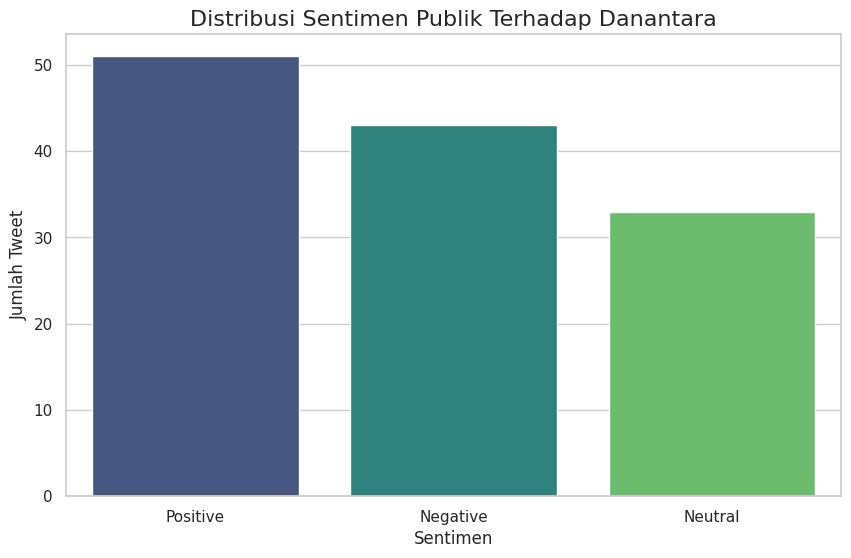

In [18]:
#--------------------------------------------------
# BAGIAN 1: INSTALASI & SETUP
#--------------------------------------------------
try:
    import langchain_community
except ImportError:
    print("Menginstal library yang dibutuhkan...")
    !pip install -q langchain_community replicate pandas matplotlib seaborn

import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata
from langchain_community.llms import Replicate
from IPython.display import display, Markdown

print("Semua library berhasil diimpor.")

# Setup API Token dan Model
try:
    api_token = userdata.get('api_token')
    os.environ["REPLICATE_API_TOKEN"] = api_token
    model = Replicate(
        model="ibm-granite/granite-3.2-8b-instruct",
        model_kwargs={"temperature": 0.75, "max_new_tokens": 200, "stop_sequences": "\n\n"}
    )
    print("Model AI berhasil di-setup.")
except Exception as e:
    print(f"Gagal setup API Key atau Model. Pastikan Anda sudah menyimpannya di Colab Secrets. Error: {e}")
    model = None

#--------------------------------------------------
# BAGIAN 2: MEMUAT DATASET
#--------------------------------------------------
df = pd.DataFrame()
if model:
    url = 'https://raw.githubusercontent.com/joynard/hacktiv8-project/main/data_clean_danantara.csv'
    try:
        df = pd.read_csv(url)
        print(f"Dataset Danantara berhasil dimuat dengan {df.shape[0]} baris.")
    except Exception as e:
        print(f"Gagal memuat dataset. Pastikan URL benar. Error: {e}")

#--------------------------------------------------
# BAGIAN 3: FUNGSI, PEMROSESAN, DAN PARSING
#--------------------------------------------------
if not df.empty:
    def klasifikasi_sentimen_danantara(tweet):
        prompt = f"""
Analyze the sentiment of the following tweet about 'Danantara'.
Classify the sentiment as Positive, Negative, or Neutral and provide a brief reason for the classification.

Tweet: "{tweet}"

Answer format:
Sentiment: [Your answer here]
Reason: [Your reason here]
"""
        try:
            return model.invoke(prompt)
        except Exception as e:
            return f"Error: {e}"

    def parse_hasil(hasil_text):
        try:
            sentiment_match = re.search(r"Sentiment:\s*(.*?)\s*(?:Reason:|$)", hasil_text, re.DOTALL)
            sentiment = sentiment_match.group(1).strip() if sentiment_match else "Tidak Terdefinisi"
            reason_match = re.search(r"Reason:\s*(.*)", hasil_text, re.DOTALL)
            reason = reason_match.group(1).strip() if reason_match else "Tidak ada alasan"
            return pd.Series([sentiment, reason])
        except Exception:
            return pd.Series(["Error Parsing", "Error Parsing"])

    # --- Proses Klasifikasi Keseluruhan Dataset ---
    print(f"\nMemulai proses klasifikasi untuk {df.shape[0]} tweet. Ini mungkin akan memakan waktu...")
    df['Hasil_Analisis'] = df['tweets'].apply(klasifikasi_sentimen_danantara)
    print("Proses klasifikasi untuk seluruh dataset selesai!")

    # --- Proses Parsing Hasil ---
    print("\nMem-parsing hasil analisis menjadi kolom terstruktur...")
    df[['Sentimen', 'Alasan']] = df['Hasil_Analisis'].apply(parse_hasil)
    print("Parsing selesai.")

    #--------------------------------------------------
    # BAGIAN 4: PREVIEW, ANALISIS & VISUALISASI
    #--------------------------------------------------
    # --- Menampilkan 5 Sampel Hasil Akhir ---
    print("\n--- Pratinjau 5 Hasil Analisis Pertama ---")
    display(df[['tweets', 'Sentimen', 'Alasan']].head(5))

    # --- Analisis Kuantitatif ---
    sentiment_counts = df['Sentimen'].value_counts()
    print("\n--- Jumlah Total Sentimen Publik ---")
    print(sentiment_counts)

    # --- Visualisasi ---
    print("\n--- Visualisasi Distribusi Sentimen ---")
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
    plt.title('Distribusi Sentimen Publik Terhadap Danantara', fontsize=16)
    plt.xlabel('Sentimen', fontsize=12)
    plt.ylabel('Jumlah Tweet', fontsize=12)
    plt.show()
else:
    print("\nProses tidak dapat dilanjutkan karena dataset gagal dimuat atau model tidak siap.")